#**Project Title**
E-Commerce Customer Behavior Analysis bold textsis

#**Objective (Problem Statement)**

1. Identify meaningful patterns and trends in e-commerce customer behavior.
2. Clean and preprocess the dataset.
3. Perform exploratory data analysis.
4. Create meaningful visualizations.
5. Generate actionable business insights and recommendations.

#**Outcome**
This project provides an overall understanding of e-commerce customer behavior and sales performance. Through data preprocessing, exploratory data analysis, statistical analysis, and visualizations, important patterns and relationships in customer purchases can be identified.

The findings can help businesses improve product strategies, customer engagement, sales performance, discount strategies, payment options, delivery services, and customer satisfaction.

#**Domain**
E-commerce / Retail

#**Dataset Information**

**Source:** Hugging Face Dataset Repository

**Dataset:** Saturia / e-commerce

**Link:** https://huggingface.co/datasets/Saturia/e-commerce

**Year / Timeline:** January 2023 to March 2024

**Dataset Column/features Description:**

* **Order_ID** - Unique identification number.

* **Customer_ID** - Unique identification number.

* **Date** - Date on which the order was placed.

* **Age** - Age of the customer.

* **Gender** - Gender of the customer.

* **City** - City where the customer is located.

* **Product_Category** - Category of the product purchased.

* **Unit_Price** - Price of one unit of the product.

* **Quantity** - Number of units purchased in the order.

* **Discount_Amount** - Discount amount applied to the order.

* **Total_Amount** - Final total amount of the order after discount.

* **Payment_Method** - Payment method used by the customer.

* **Device_Type** - Device used by the customer for the purchase.

* **Session_Duration_Minutes** - Duration of the customer's online shopping session in minutes.

* **Pages_Viewed** - Number of pages viewed by the customer during the session.

* **Is_Returning_Customer** - Indicates whether the customer is a returning customer.

* **Delivery_Time_Days** - Number of days required to deliver the order.

* **Customer_Rating** - Rating provided by the customer.

#**Stages of DA Project**

#stage 1- Problem defination and dataset selection
#Problem Defination
The business has lots of e-commerce transaction data, but it needs to understand who buys, what they buy, how they buy, how much they spend, and what factors affect their experience
#Dataset selection
The E-commerce Customer Behavior Dataset was selected because it contains 5,000 transaction records and 18 features related to customer behavior, sales, products, payments, and delivery. It is suitable for performing data cleaning, EDA, visualization, and generating useful business insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
file_path = "/content/ecommerce_customer_behavior_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [4]:
# Dataset Preview
df.head()


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [5]:
# Dataset Shape
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5000
Number of Columns: 18


In [6]:
# Data Types
df.dtypes

,0
Order_ID,object
Customer_ID,object
Date,object
Age,int64
Gender,object
City,object
Product_Category,object
Unit_Price,float64
Quantity,int64
Discount_Amount,float64


In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [8]:
# Statistical Summary
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


In [9]:
# Checking Missing Values
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Date,0
Age,0
Gender,0
City,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount_Amount,0


In [10]:
# Checking Duplicate Values
df.duplicated().sum()

np.int64(0)

##Stage 2- Data cleaning and pre processing

In [11]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import files
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [12]:
# Upload the Dataset

from google.colab import files

uploaded = files.upload()

Saving ecommerce_customer_behavior_dataset.csv to ecommerce_customer_behavior_dataset (1).csv


In [13]:
# Load the Dataset

df = pd.read_csv("ecommerce_customer_behavior_dataset.csv")

In [14]:
# 2. Check Missing Values

missing_values = df.isnull().sum()
display(missing_values)

,0
Order_ID,0
Customer_ID,0
Date,0
Age,0
Gender,0
City,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount_Amount,0


In [15]:
# 3. Check Duplicate Values

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
# 4. Check Column Names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating']


In [17]:
# 5. Check Data Types
print(df.dtypes)

Order_ID                     object
Customer_ID                  object
Date                         object
Age                           int64
Gender                       object
City                         object
Product_Category             object
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method               object
Device_Type                  object
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object


In [18]:
# 6. Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)

datetime64[ns]


In [19]:
# 7. Check Categorical Values

categorical_columns = [
    'Gender',
    'City',
    'Product_Category',
    'Payment_Method',
    'Device_Type',
    'Is_Returning_Customer'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Female' 'Male' 'Other']

City:
['Bursa' 'Konya' 'Ankara' 'Istanbul' 'Izmir' 'Eskisehir' 'Antalya'
 'Kayseri' 'Gaziantep' 'Adana']

Product_Category:
['Toys' 'Food' 'Electronics' 'Sports' 'Beauty' 'Fashion' 'Home & Garden'
 'Books']

Payment_Method:
['Debit Card' 'Credit Card' 'Cash on Delivery' 'Digital Wallet'
 'Bank Transfer']

Device_Type:
['Mobile' 'Desktop' 'Tablet']

Is_Returning_Customer:
[ True False]


In [20]:
# 8. Convert Numeric Columns

numeric_columns = [
    'Age',
    'Unit_Price',
    'Quantity',
    'Discount_Amount',
    'Total_Amount',
    'Session_Duration_Minutes',
    'Pages_Viewed',
    'Delivery_Time_Days',
    'Customer_Rating'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_columns].dtypes)

Age                           int64
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object


In [21]:
# 9. Clean Categorical Columns

categorical_columns = [
    'Gender',
    'City',
    'Product_Category',
    'Payment_Method',
    'Device_Type',
    'Is_Returning_Customer'
]

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

In [22]:
# 10. Recheck Missing Values After Cleaning

missing_after_cleaning = df.isnull().sum()

print("Missing Values After Cleaning:")
print(missing_after_cleaning)

Missing Values After Cleaning:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64


In [23]:
# 12. Create Gross Amount

df['Gross_Amount'] = df['Unit_Price'] * df['Quantity']

display(df[['Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Gross_Amount']].head())

,Unit_Price,Quantity,Discount_Amount,Total_Amount,Gross_Amount
0,54.28,1,0.00,54.28,54.28
1,244.90,1,0.00,244.90,244.90
2,48.15,5,0.00,240.75,240.75
3,804.06,1,229.28,574.78,804.06
4,755.61,5,0.00,3778.05,3778.05


In [24]:
# 13. Create Discount Percentage

df['Discount_Percentage'] = (
    df['Discount_Amount'] / df['Gross_Amount']
) * 10

display(df[['Gross_Amount', 'Discount_Amount',
            'Discount_Percentage', 'Total_Amount']].head())

,Gross_Amount,Discount_Amount,Discount_Percentage,Total_Amount
0,54.28,0.00,0.000000,54.28
1,244.90,0.00,0.000000,244.90
2,240.75,0.00,0.000000,240.75
3,804.06,229.28,2.851528,574.78
4,3778.05,0.00,0.000000,3778.05


In [25]:
# 14. Create Year and Month Columns

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

display(df[['Date', 'Year', 'Month', 'Month_Name']].head())

,Date,Year,Month,Month_Name
0,2023-01-01,2023,1,January
1,2023-01-01,2023,1,January
2,2023-01-01,2023,1,January
3,2023-01-01,2023,1,January
4,2023-01-01,2023,1,January


In [26]:
# 15. Create Age Groups

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Below 18', '18-25', '26-35', '36-45', '46-55', '56-65', 'Above 65']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(df[['Age', 'Age_Group']].head())

,Age,Age_Group
0,27,26-35
1,42,36-45
2,43,36-45
3,32,26-35
4,40,36-45


In [27]:
# 16. Create Net Amount

df['Net_Amount'] = df['Gross_Amount'] - df['Discount_Amount']

print("Net_Amount column created successfully.")

display(df[['Gross_Amount',
            'Discount_Amount',
            'Net_Amount',
            'Total_Amount']].head())

Net_Amount column created successfully.


,Gross_Amount,Discount_Amount,Net_Amount,Total_Amount
0,54.28,0.00,54.28,54.28
1,244.90,0.00,244.90,244.90
2,240.75,0.00,240.75,240.75
3,804.06,229.28,574.78,574.78
4,3778.05,0.00,3778.05,3778.05


## Stage 3 – EDA and Visualizations

In [28]:
# Descriptive Analysis

print("Descriptive Statistics of Numerical Variables:")

display(df.describe())

Descriptive Statistics of Numerical Variables:


,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Gross_Amount,Discount_Percentage,Year,Month,Net_Amount
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2023-08-16 09:16:24.959999744,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800,1007.961718,0.332316,2023.190600,5.731200,983.108914
min,2023-01-01 00:00:00,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000,7.870000,0.000000,2023.000000,1.000000,7.870000
25%,2023-04-30 00:00:00,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000,128.577500,0.000000,2023.000000,2.000000,122.517500
50%,2023-08-17 00:00:00,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000,348.540000,0.000000,2023.000000,5.000000,337.910000
75%,2023-12-06 00:00:00,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000,1014.247500,0.391931,2023.000000,9.000000,979.695000
max,2024-03-26 00:00:00,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000,22023.900000,2.993492,2024.000000,12.000000,22023.900000
std,NaN,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542,1931.478036,0.654911,0.392814,3.619885,1898.978528


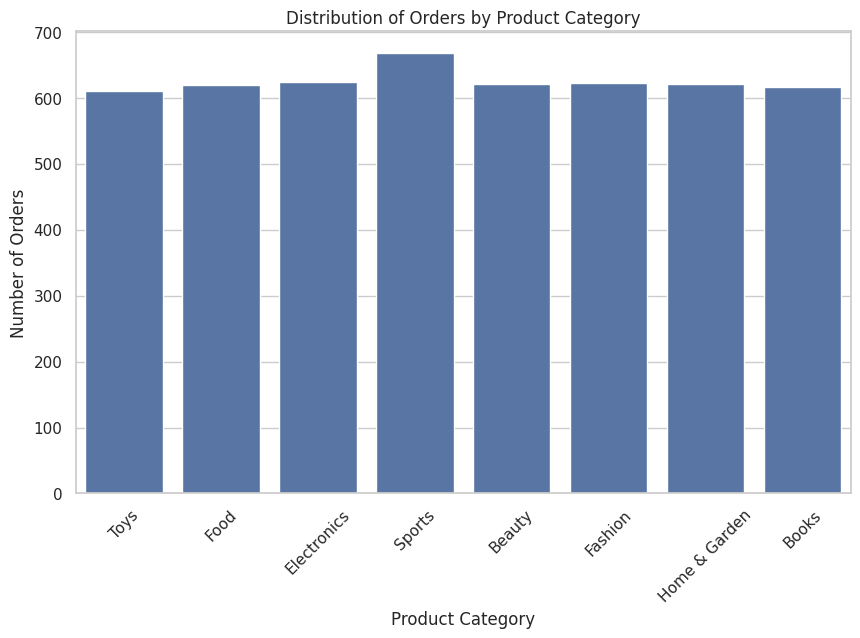

In [29]:
# 1. Product Category Distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Product_Category'
)

plt.title('Distribution of Orders by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.show()

### Insights
- The chart shows the number of orders across different product categories.
- The order frequency varies across the categories.
- The chart helps identify the categories with relatively higher and lower order counts.
- This information can be useful for understanding customer product preferences.

### Interpretation of the Above Chart

The countplot represents the distribution of orders across different product categories.

**Feature used:** Product_Category

The chart counts the number of orders for each product category and helps us compare the popularity of different categories. From this visualization, we can understand which categories receive more or fewer orders and use this information for further sales and customer-behavior analysis.

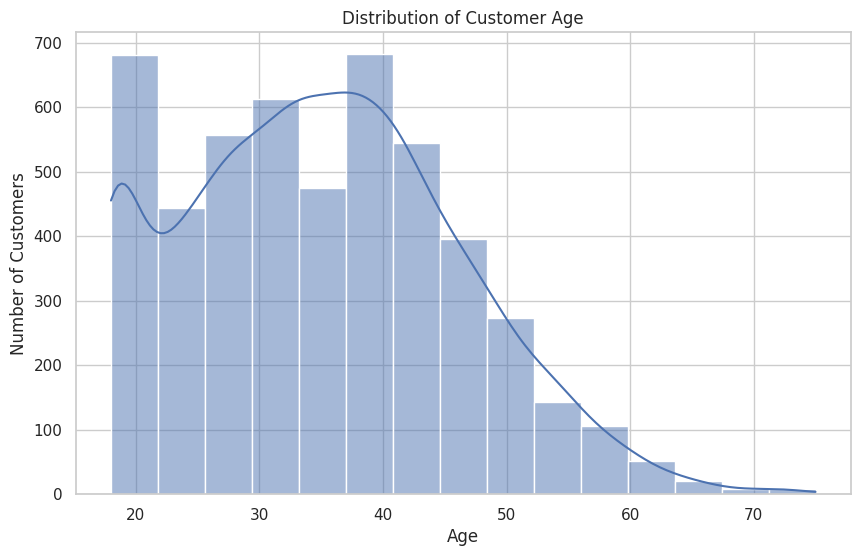

In [30]:
# 2. Age Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Age',
    bins=15,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

### Insights

- The histogram shows the distribution of customer ages in the dataset.
- Customers are distributed across different age groups.
- The tallest bars indicate the age ranges with a higher number of customers.
- The distribution helps us understand the demographic profile of the customers.
- Age can be useful for further analysis of purchasing behavior and customer preferences.

## Interpretation of the Above Chart

The histogram represents the distribution of customer ages in the e-commerce dataset.

The chart shows how customers are distributed across different age ranges. It helps identify the age groups that are more commonly represented in the dataset.

The main feature used is **Age**. The histogram groups customer ages into different intervals and shows the number of customers in each interval.

This chart shows the age profile of the customers in the dataset. It helps us understand the customer demographics and provides a basis for analyzing purchasing behavior across different age groups.

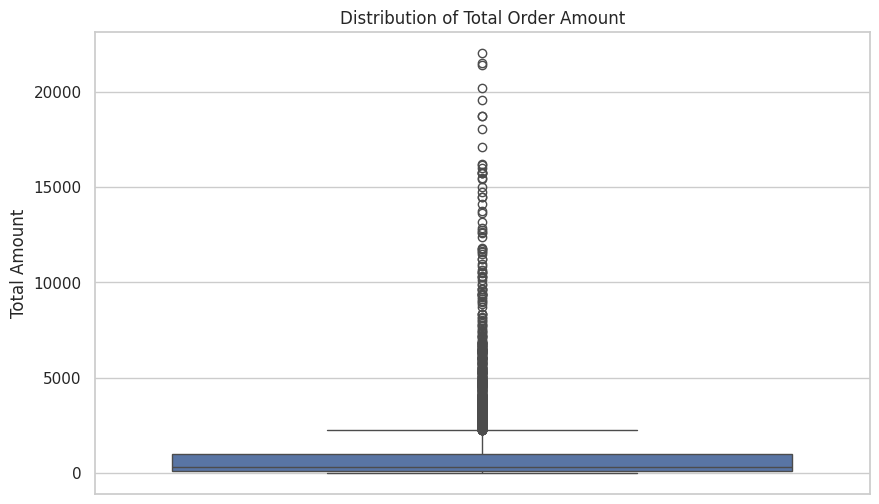

In [31]:
# 3. Total Amount Distribution

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    y='Total_Amount'
)

plt.title('Distribution of Total Order Amount')
plt.ylabel('Total Amount')

plt.show()

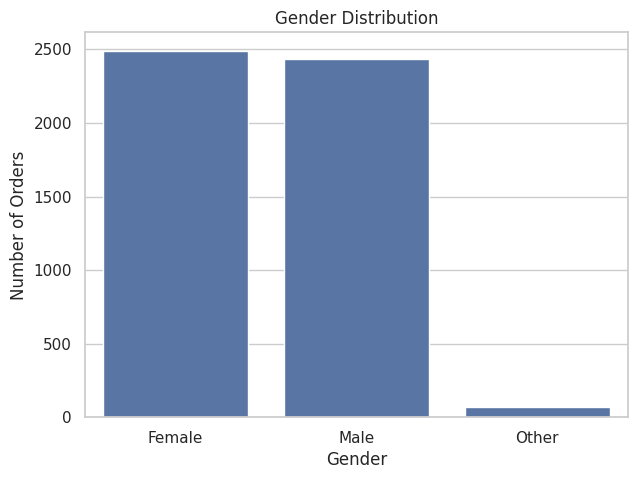

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Gender')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Orders')

plt.show()

### Insights

- The boxplot shows the distribution of total order amounts.
- It shows the median, spread, and variation in the order amounts.
- The box represents the middle 50% of the order values.
- The points outside the main distribution indicate potential outliers.
- This helps identify unusually high or low order amounts in the dataset.

## Interpretation of the Above Chart

The boxplot represents the distribution of **Total_Amount** for the orders in the e-commerce dataset

The chart shows how the total order amounts are distributed and highlights the variation between different orders. It also helps identify potential outliers.

The main feature used is **Total_Amount**, which represents the final amount associated with each order.

This chart shows the spread and variation of order values in the dataset. It helps us understand the typical order amount and identify unusually high or low order values.

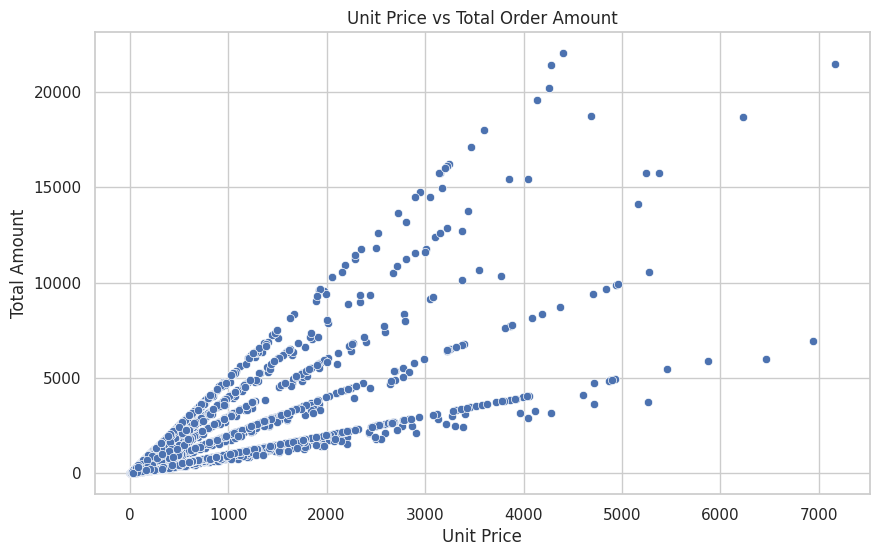

In [33]:
# 4. Unit Price vs Total Amount

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Unit_Price',
    y='Total_Amount'
)

plt.title('Unit Price vs Total Order Amount')
plt.xlabel('Unit Price')
plt.ylabel('Total Amount')

plt.show()

### Insights

- The scatterplot shows the relationship between Unit Price and Total Amount.
- It helps us observe how changes in unit price are associated with changes in the total order amount.
- The points show the variation in total order amounts for different unit prices.
- Some observations may be farther away from the general pattern, indicating unusual order values.
- This analysis helps us understand the relationship between product price and overall order value.

## Interpretation of the Above Chart

The scatterplot represents the relationship between **Unit_Price** and **Total_Amount** for the orders in the e-commerce dataset.

The chart shows how the total order amount varies with the unit price of products. The distribution of points helps us observe whether there is a relationship between these two variables.

The features used are **Unit_Price** and **Total_Amount**. Unit_Price is shown on the X-axis, while Total_Amount is shown on the Y-axis.

This chart shows the relationship between product unit price and total order amount. It helps us understand how product pricing may be associated with the overall value of an order.

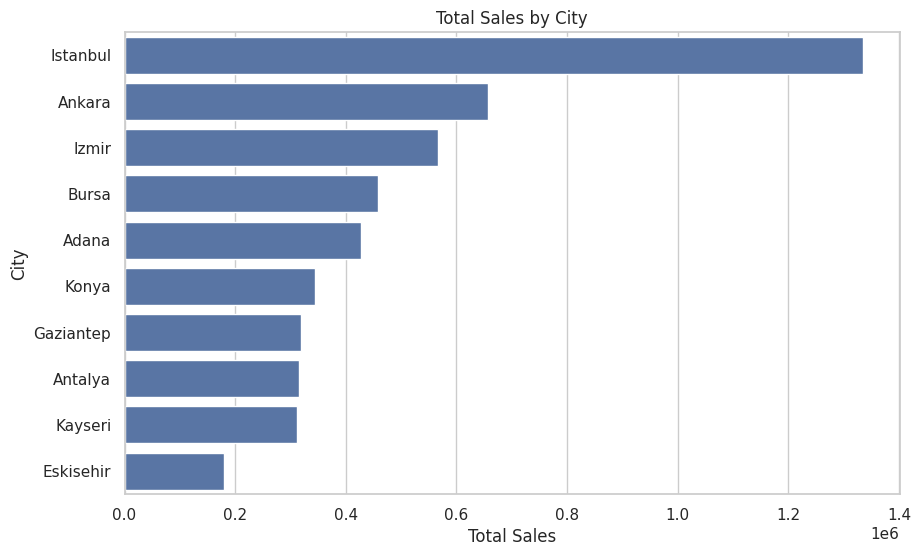

In [34]:
# 5. Total Sales by City

city_sales = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title('Total Sales by City')
plt.xlabel('Total Sales')
plt.ylabel('City')

plt.show()

### Insights

- The barplot shows the total sales generated by each city.
- The sales amount varies across different cities.
- The chart allows us to compare the sales contribution of each city.
- Cities with higher bars contribute a larger amount to the overall sales.
- This analysis helps identify differences in sales performance across locations.

## Interpretation of the Above Chart

The barplot represents the total sales generated by different cities in the e-commerce dataset.

The chart compares the total order amount across cities and shows how sales are distributed geographically.

The features used are **City** and **Total_Amount**. The City feature is used to group the orders, while Total_Amount is summed to calculate the total sales for each city.

This chart shows the sales performance of different cities. It helps us understand how much each city contributes to the overall sales and identify differences in sales across locations.

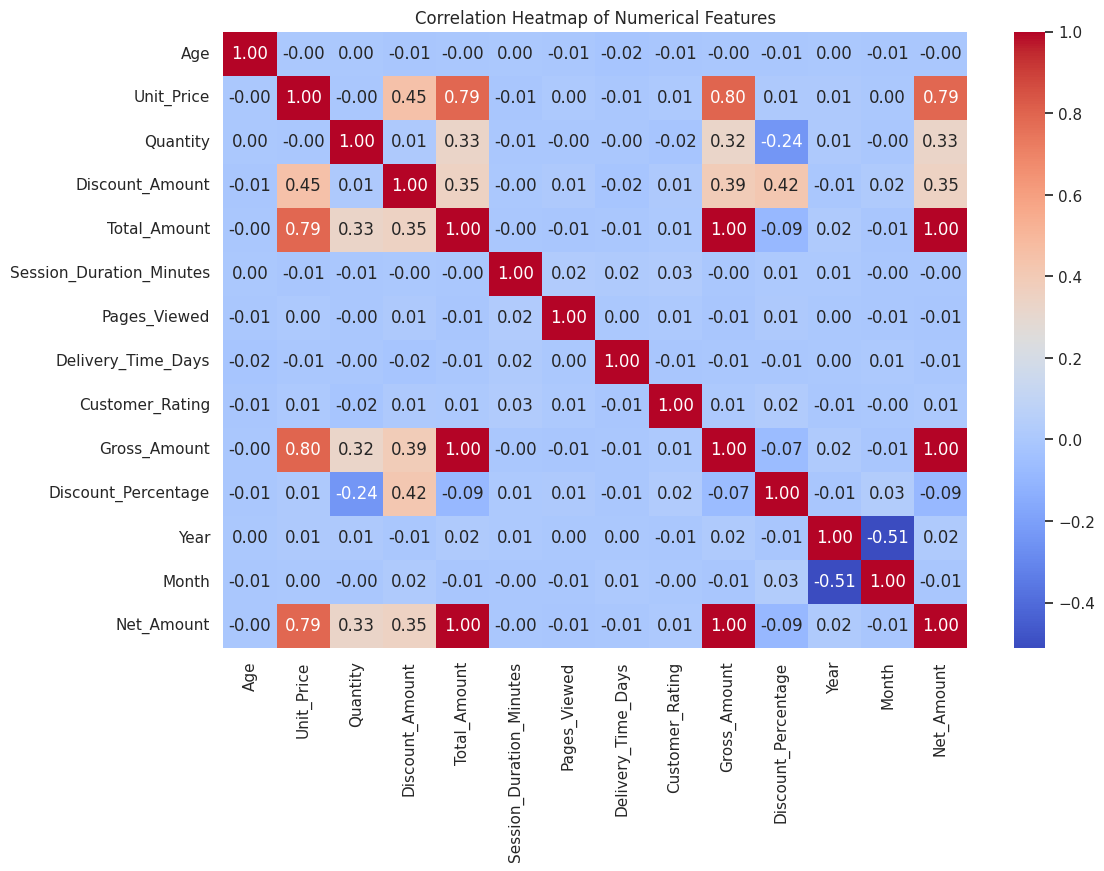

In [35]:
# 6. Correlation Heatmap

numeric_data = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insights

- The heatmap shows the correlation between the numerical features in the dataset.
- Correlation values range from -1 to +1.
- Values closer to +1 indicate a stronger positive relationship.
- Values closer to -1 indicate a stronger negative relationship.
- Values closer to 0 indicate a weaker linear relationship.
- The heatmap helps identify important relationships that can be explored further in the analysis.

## Interpretation of the Above Chart

The correlation heatmap represents the relationships between the numerical features in the e-commerce dataset.

The chart shows the strength and direction of relationships between different numerical variables using correlation values.

The analysis uses the numerical features such as **Age, Unit_Price, Quantity, Discount_Amount, Total_Amount, Session_Duration_Minutes, Pages_Viewed, Delivery_Time_Days, and Customer_Rating**.

This chart shows which numerical features have stronger or weaker relationships with each other. It helps identify relationships that can be investigated further during the EDA.

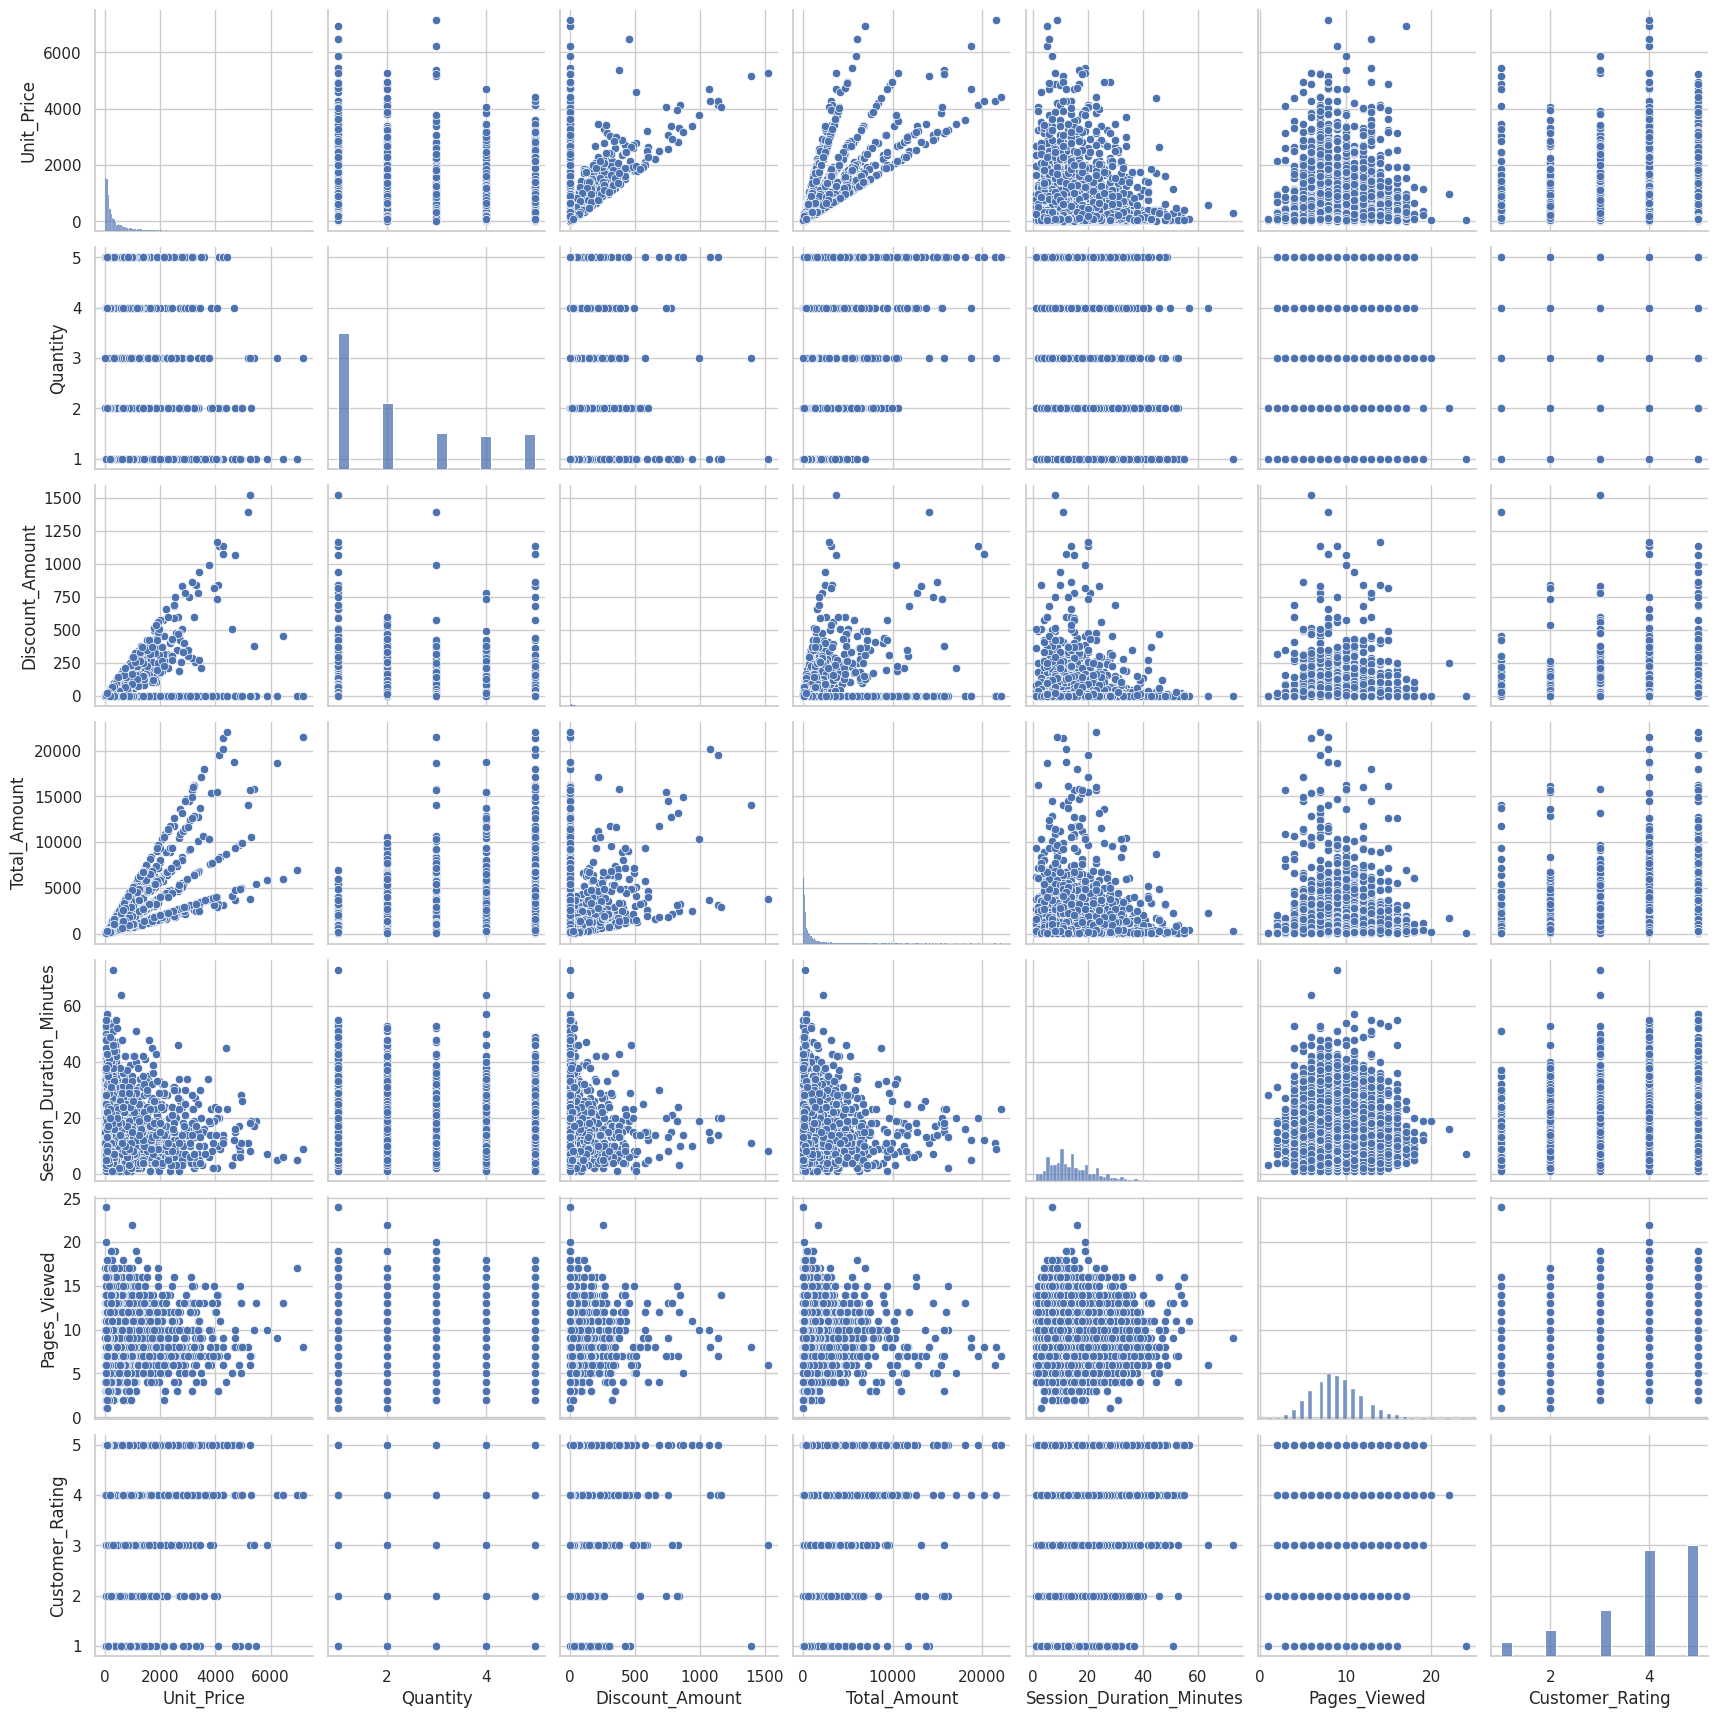

In [36]:
# 7. Pairplot of Numerical Features

selected_columns = [
    'Unit_Price',
    'Quantity',
    'Discount_Amount',
    'Total_Amount',
    'Session_Duration_Minutes',
    'Pages_Viewed',
    'Customer_Rating'
]

sns.pairplot(df[selected_columns])

plt.show()

### Insights

- The pairplot shows the relationships between multiple numerical features simultaneously.
- It helps identify possible positive or negative relationships between variables.
- The diagonal plots show the individual distribution of each numerical feature.
- The scatterplots show relationships between pairs of numerical features.
- It helps identify patterns, clusters, and possible outliers in the dataset.

## Interpretation of the Above Chart

The pairplot represents the relationships and distributions of selected numerical features in the e-commerce dataset.

It shows how different numerical variables are related to each other and helps identify visible patterns in the data.

The features used are **Unit_Price, Quantity, Discount_Amount, Total_Amount, Session_Duration_Minutes, Pages_Viewed, and Customer_Rating**.

This chart provides a multivariate view of the dataset and helps us understand relationships between multiple numerical variables at the same time.

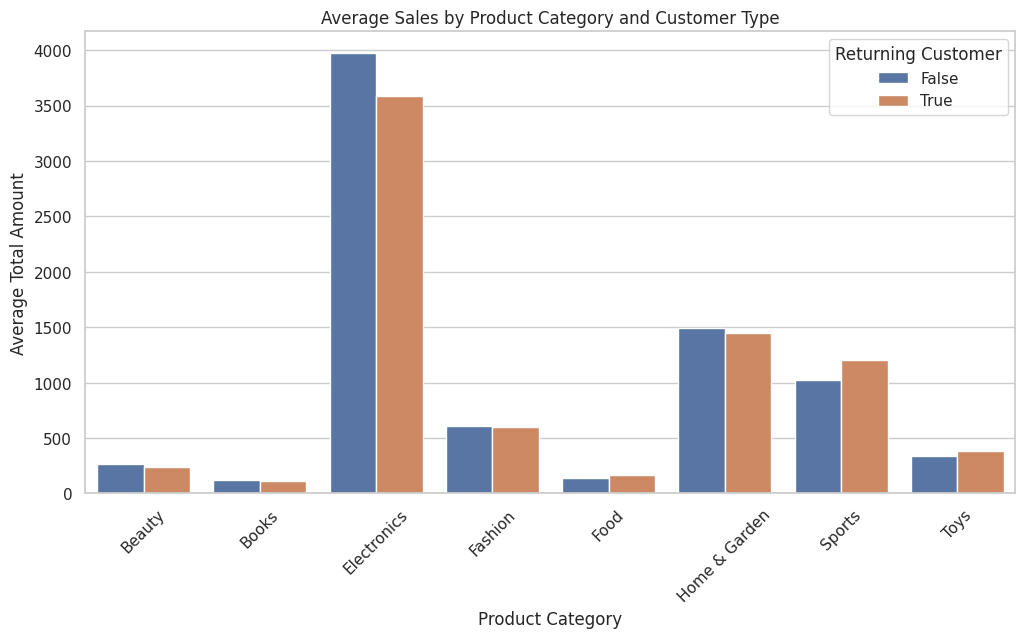

In [37]:
# 8. Average Sales by Product Category and Customer Type

grouped_data = df.groupby(
    ['Product_Category', 'Is_Returning_Customer']
)['Total_Amount'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=grouped_data,
    x='Product_Category',
    y='Total_Amount',
    hue='Is_Returning_Customer'
)

plt.title('Average Sales by Product Category and Customer Type')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=45)
plt.legend(title='Returning Customer')

plt.show()

### Insights

- The grouped barplot compares average order amounts across different product categories.
- It also compares the average sales between returning and non-returning customers.
- The chart helps identify differences in purchasing value across product categories and customer types.
- Some product categories may show higher average order values for one customer type than the other.
- This analysis helps understand customer purchasing behavior across different product categories.

## Interpretation of the Above Chart

The grouped barplot represents the average total order amount for different product categories, divided by customer type.

The chart shows how the average order value varies across product categories and between returning and non-returning customers.

The features used are **Product_Category**, **Is_Returning_Customer**, and **Total_Amount**.

This chart shows differences in average purchasing value across product categories and customer types. It helps us understand how returning customer status is associated with purchasing behavior.

In [38]:
# 9. Pivot Table - Sales by City and Product Category

pivot_table = pd.pivot_table(
    df,
    values='Total_Amount',
    index='City',
    columns='Product_Category',
    aggfunc='sum'
)

display(pivot_table)

Product_Category,Beauty,Books,Electronics,Fashion,Food,Home & Garden,Sports,Toys
City,,,,,,,,
Adana,13332.53,6693.41,234434.40,24053.83,3441.71,55252.36,72894.54,16956.85
Ankara,20055.91,10349.69,306703.00,50752.68,15766.04,108307.93,112636.74,32963.83
Antalya,11059.05,5544.10,150048.13,16681.66,7895.06,70243.13,38834.39,15244.37
Bursa,18777.17,7525.35,187055.25,41849.47,10253.76,99528.52,68113.80,25972.99
Eskisehir,7353.97,4273.24,69321.33,14637.99,5920.44,44231.40,25060.04,8180.02
Gaziantep,7751.87,5170.14,160398.60,31406.09,7035.34,45942.40,46450.45,14253.52
Istanbul,43040.41,20790.86,619907.93,106812.42,23280.16,261927.24,202157.75,56205.79
Izmir,19089.17,5750.74,252927.12,49398.05,11621.88,113476.16,88536.79,26734.76
Kayseri,9065.04,2342.01,194896.35,14248.84,4127.64,37703.77,38214.55,11705.71


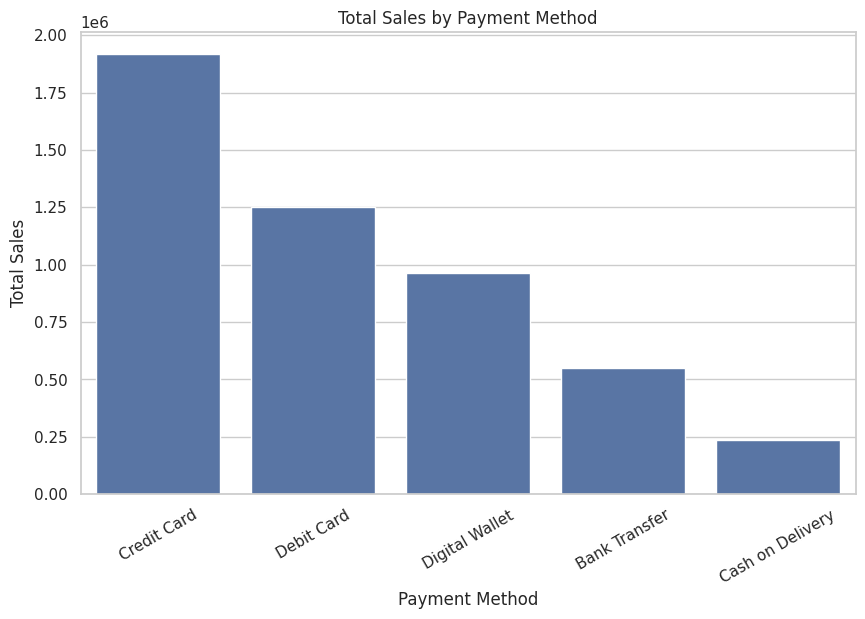

In [39]:
# 10. Total Sales by Payment Method

payment_sales = df.groupby('Payment_Method')['Total_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values
)

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)

plt.show()

### Insights

- The barplot shows the total sales generated through different payment methods.
- It allows us to compare the contribution of each payment method to overall sales.
- The sales amount varies across the different payment methods.
- This analysis helps understand customer payment preferences in relation to sales.
- The results can help businesses evaluate the usage of different payment options.

## Interpretation of the Above Chart

The barplot represents the total sales generated through different payment methods in the e-commerce dataset.

The chart shows how total sales are distributed across the different payment methods used by customers.

The features used are **Payment_Method** and **Total_Amount**. The Total_Amount values are summed for each payment method.

This chart shows the sales contribution associated with different payment methods and helps us understand customer payment preferences.

In [40]:
# 11. Descriptive Analysis - Sales by Product Category

category_sales = df.groupby('Product_Category')['Total_Amount'].agg(
    ['sum', 'mean', 'count']
).sort_values('sum', ascending=False)

display(category_sales)

,sum,mean,count
Product_Category,,,
Electronics,2328806.81,3732.062196,624
Home & Garden,908348.86,1462.719581,621
Sports,754563.56,1131.279700,667
Fashion,375214.93,603.239437,622
Toys,223142.48,365.807344,610
Beauty,156584.74,252.149340,621
Food,96138.67,155.312876,619
Books,72744.52,118.091753,616


### Insights

- The table summarizes sales performance across different product categories.
- It shows the total sales, average order amount, and number of orders for each category.
- The total sales value helps compare the overall contribution of each product category.
- The average order amount helps understand the typical value of orders within each category.
- The order count shows the number of transactions recorded for each category.

## Interpretation of the Above Analysis

The descriptive analysis summarizes the sales performance of different product categories using total sales, average order amount, and number of orders.

It shows how different product categories contribute to sales and how frequently customers purchase products from each category.

The features used are **Product_Category** and **Total_Amount**. The Total_Amount is analyzed using **sum, mean, and count**.

This analysis provides an overall summary of product category performance and helps understand differences in sales value, average order value, and order frequency.

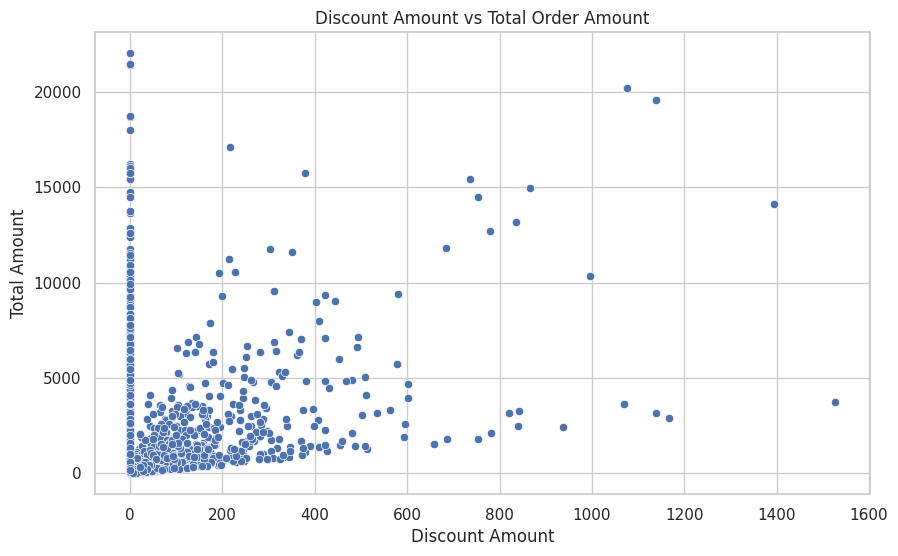

In [41]:
# 12. Diagnostic Analysis - Discount vs Total Amount

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount_Amount',
    y='Total_Amount'
)

plt.title('Discount Amount vs Total Order Amount')
plt.xlabel('Discount Amount')
plt.ylabel('Total Amount')

plt.show()

### Insights

- The scatterplot shows the relationship between Discount Amount and Total Amount.
- It helps us examine whether changes in discount amount are associated with changes in total order value.
- The distribution of points shows the variation in order amounts at different discount levels.
- Some points may represent orders with unusually high or low discount or total amounts.
- This analysis helps investigate how discounting is associated with order value.

## Interpretation of the Above Chart

The scatterplot represents the relationship between **Discount_Amount** and **Total_Amount** in the e-commerce dataset

The chart shows how total order amounts vary with different discount amounts and helps identify any visible relationship between the two variables.

The features used are **Discount_Amount** and **Total_Amount**. Discount_Amount is shown on the X-axis, while Total_Amount is shown on the Y-axis.

This chart helps us investigate whether the discount amount is associated with the total value of an order and identify unusual observations that may require further analysis.

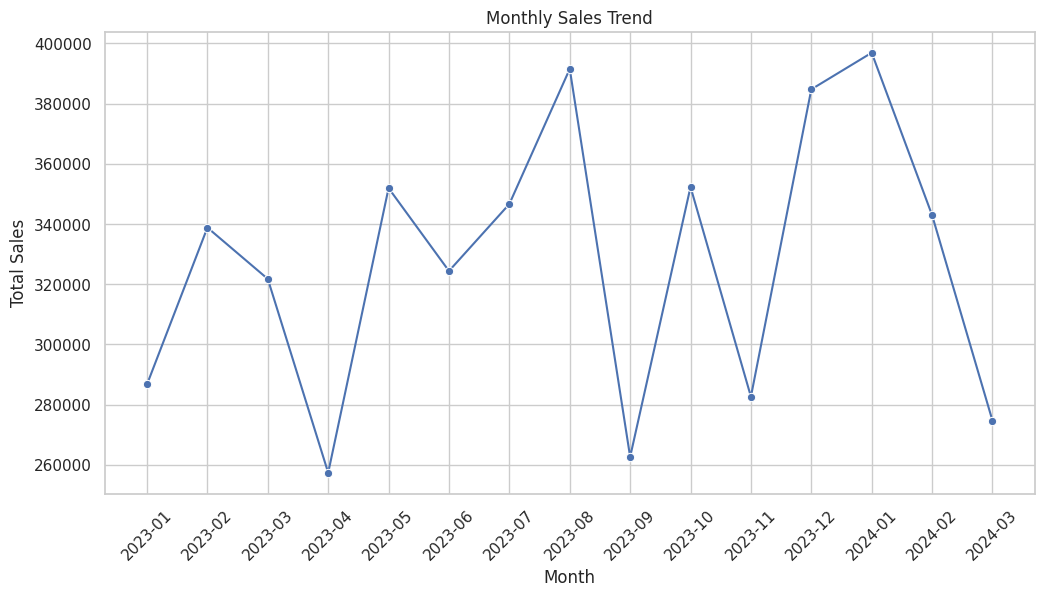

In [42]:
# 14. Monthly Sales Trend

monthly_sales = df.groupby(
    ['Year', 'Month']
)['Total_Amount'].sum().reset_index()

monthly_sales['Year_Month'] = (
    monthly_sales['Year'].astype(str) + '-' +
    monthly_sales['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='Year_Month',
    y='Total_Amount',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

### Insights

- The line chart shows how total sales change over time on a monthly basis.
- It helps identify increases and decreases in sales during different months.
- The chart makes it easier to observe overall sales trends across the available period.
- Monthly variations can help identify periods of relatively higher or lower sales.
- This analysis provides a time-based view of the e-commerce sales performance.

## Interpretation of the Above Chart

The line chart represents the monthly sales trend in the e-commerce dataset.

It shows how the total sales amount changes from month to month during the dataset's time period.

The features used are **Date** and **Total_Amount**. The Date feature is used to group orders by month, while Total_Amount is summed to calculate monthly sales.

This chart shows the sales trend over time and helps identify changes in monthly sales performance.

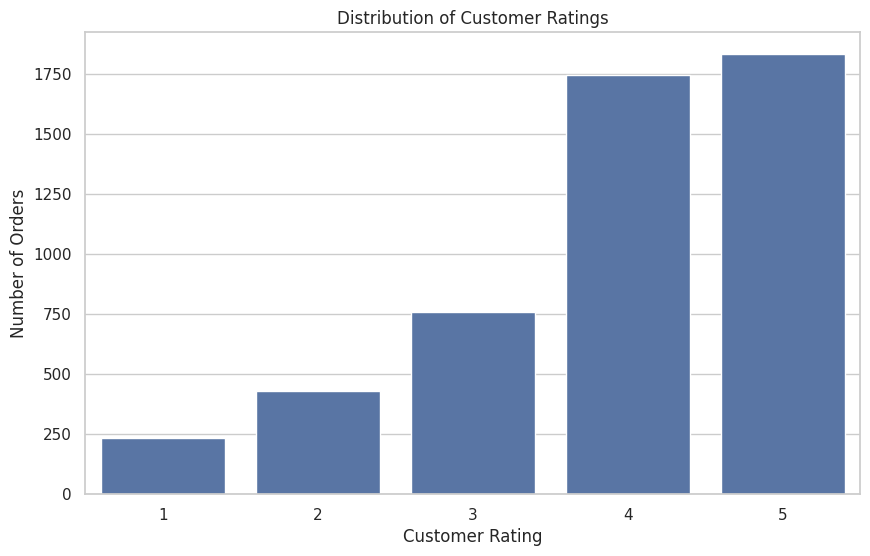

In [43]:
# 15. Customer Rating Distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Customer_Rating'
)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Customer Rating')
plt.ylabel('Number of Orders')

plt.show()

### Insights

- The countplot shows the distribution of customer ratings in the dataset.
- It allows us to compare how frequently each rating value occurs.
- The distribution provides an overview of customer satisfaction levels.
- Higher or lower concentrations of ratings can indicate differences in customer satisfaction.
- This analysis can help identify the general pattern of customer feedback.

## Interpretation of the Above Chart

The countplot represents the distribution of customer ratings given for orders in the e-commerce dataset.

It shows the number of orders associated with each customer rating and allows us to compare the frequency of different ratings.

The main feature used is **Customer_Rating**, which represents the rating provided by customers.

This chart shows the distribution of customer ratings and provides an overview of customer satisfaction based on the ratings recorded in the dataset.

In [44]:
# Export Cleaned Dataset for Power BI

df.to_csv('ecommerce_cleaned_data.csv', index=False)

print("Cleaned dataset exported successfully.")
print("File name: ecommerce_cleaned_data.csv")

Cleaned dataset exported successfully.
File name: ecommerce_cleaned_data.csv


In [45]:
from google.colab import files

files.download('ecommerce_cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>